<a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/heeyeon/advanced/heeyeon/session06/generativemodel%20(1)" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/main/advanced/template/session06/practice_generativemodel.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
  </td>
</table>


## 📁 라이브러리 임포트
- AutoEncoder, VAE, GAN은 tensorflow를 사용합니다.
- Diffusion Model은 torch를 사용합니다.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

import time
from tqdm.notebook import trange
from tqdm.keras import TqdmCallback
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import copy


## 🧮 GPU 사용하기

In [5]:
# PyTorch GPU 상태
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ [PyTorch] Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")


# TensorFlow GPU 상태
print("\n✅ [TensorFlow] GPU Devices:")
print(tf.config.list_physical_devices('GPU'))

✅ [PyTorch] Using device: cuda
GPU name: Tesla T4

✅ [TensorFlow] GPU Devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# ✍🏻 생성 모델 실습

Fashion MNIST 의류 이미지 데이터를 사용하여 3가지 생성 모델을 실습해봅시다!

1. **AutoEncoder (오토인코더)** — 입력 이미지를 압축 후 복원  
2. **GAN (Generative Adversarial Network)** — 가짜 이미지를 생성  
3. **Diffusion Model** — 노이즈로부터 이미지를 복원

## 🔍 1. AutoEncoder(오토인코더)
Fashion MNIST 의류 이미지를 압축(784차원 → 32차원)했다가 복원하는 오토인코더를 작성해 봅시다!

### 1-1.  데이터 준비
- 입력데이터 준비. Fashion MNIST 의류 이미지를 사용하며, 정답레이블은 사용하지 않습니다.
- 모든값은 0~1사이로 정규화하고 28x28이미지를 크기 784x1의 벡터로 만듭니다.

In [6]:
## Fashion MNIST 데이터 로드
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# 정규화 및 reshape
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
x_train = x_train.reshape((-1, 28, 28, 1))      #reshape()를 호출해 훈련데이터를 (배치크기, 28, 28, 1)로 설정합니다.
x_test = x_test.reshape((-1, 28, 28, 1))


print("훈련 데이터:", x_train.shape)
print("테스트 데이터:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련 데이터: (60000, 28, 28, 1)
테스트 데이터: (10000, 28, 28, 1)


### 1-2. AutoEncoder 모델 정의

In [7]:
# Conv2D 기반 오토인코더 구조입니다.
# 인코더: Conv2D + MaxPooling2D 로 특징 추출
# 디코더: Conv2D + UpSampling2D 로 이미지 복원
input_img = tf.keras.layers.Input(shape=(28, 28, 1))

# 인코더
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

# 디코더
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)  # 출력 픽셀값을 [0,1]로 제한하기 위해 sigmoid 사용 (입력 데이터 정규화가 [0,1]인 경우)

autoencoder = tf.keras.Model(input_img, decoded)


In [8]:
#모델컴파일. 먼저 화소당 MSE손실을 사용하고, optimizer로 'adam'을 사용합니다.
autoencoder.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError())

### 1-3. AutoEncoder 학습
- 이제 오토인코더를 50에폭동안 학습시켜봅시다.

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 1: val_loss improved from None to 0.01215, saving model to best_autoencoder.keras

Epoch 1: finished saving model to best_autoencoder.keras

Epoch 2: val_loss improved from 0.01215 to 0.00949, saving model to best_autoencoder.keras

Epoch 2: finished saving model to best_autoencoder.keras

Epoch 3: val_loss improved from 0.00949 to 0.00812, saving model to best_autoencoder.keras

Epoch 3: finished saving model to best_autoencoder.keras

Epoch 4: val_loss improved from 0.00812 to 0.00681, saving model to best_autoencoder.keras

Epoch 4: finished saving model to best_autoencoder.keras

Epoch 5: val_loss improved from 0.00681 to 0.00577, saving model to best_autoencoder.keras

Epoch 5: finished saving model to best_autoencoder.keras

Epoch 6: val_loss improved from 0.00577 to 0.00528, saving model to best_autoencoder.keras

Epoch 6: finished saving model to best_autoencoder.keras

Epoch 7: val_loss improved from 0.00528 to 0.00478, saving model to best_autoencoder.keras

Epoch 7: f

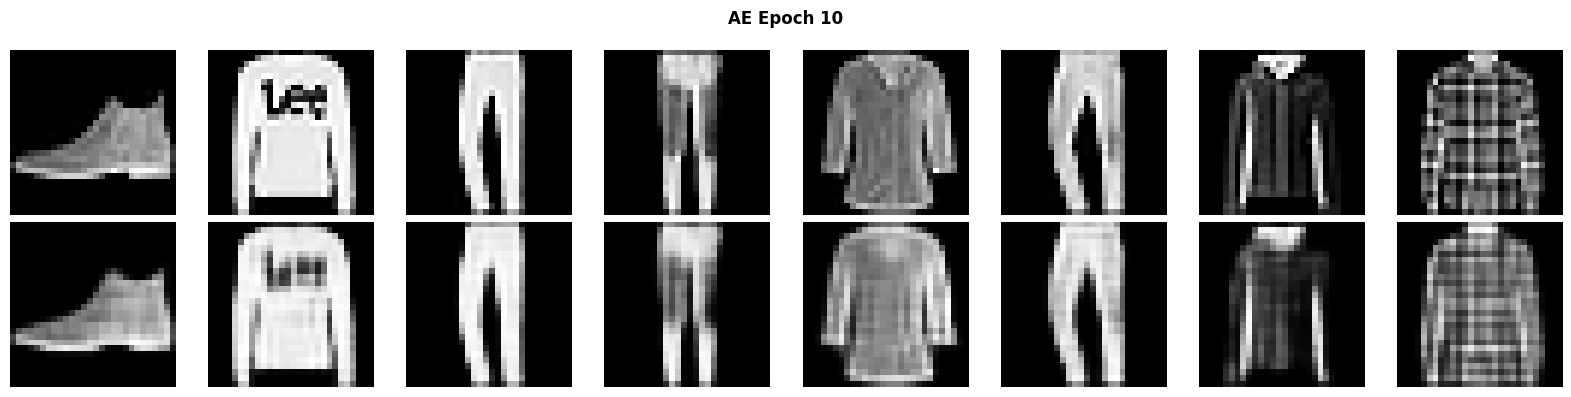


Epoch 10: val_loss improved from 0.00428 to 0.00404, saving model to best_autoencoder.keras

Epoch 10: finished saving model to best_autoencoder.keras

Epoch 11: val_loss improved from 0.00404 to 0.00385, saving model to best_autoencoder.keras

Epoch 11: finished saving model to best_autoencoder.keras

Epoch 12: val_loss did not improve from 0.00385

Epoch 13: val_loss improved from 0.00385 to 0.00351, saving model to best_autoencoder.keras

Epoch 13: finished saving model to best_autoencoder.keras

Epoch 14: val_loss improved from 0.00351 to 0.00349, saving model to best_autoencoder.keras

Epoch 14: finished saving model to best_autoencoder.keras

Epoch 15: val_loss improved from 0.00349 to 0.00329, saving model to best_autoencoder.keras

Epoch 15: finished saving model to best_autoencoder.keras

Epoch 16: val_loss did not improve from 0.00329

Epoch 17: val_loss improved from 0.00329 to 0.00318, saving model to best_autoencoder.keras

Epoch 17: finished saving model to best_autoenco

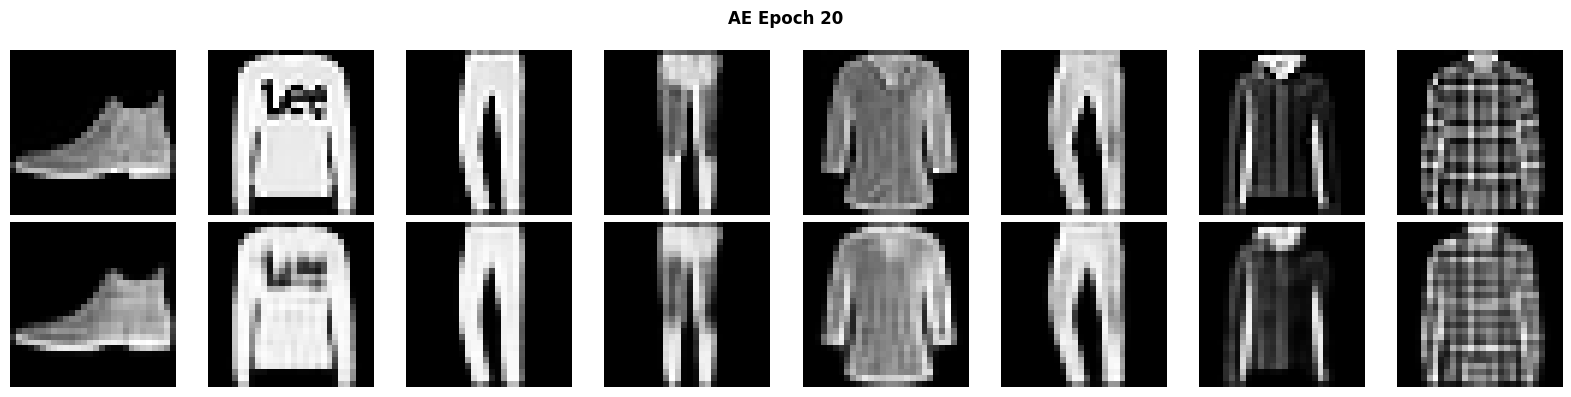


Epoch 20: val_loss improved from 0.00296 to 0.00291, saving model to best_autoencoder.keras

Epoch 20: finished saving model to best_autoencoder.keras

Epoch 21: val_loss improved from 0.00291 to 0.00291, saving model to best_autoencoder.keras

Epoch 21: finished saving model to best_autoencoder.keras

Epoch 22: val_loss improved from 0.00291 to 0.00280, saving model to best_autoencoder.keras

Epoch 22: finished saving model to best_autoencoder.keras

Epoch 23: val_loss improved from 0.00280 to 0.00277, saving model to best_autoencoder.keras

Epoch 23: finished saving model to best_autoencoder.keras

Epoch 24: val_loss improved from 0.00277 to 0.00270, saving model to best_autoencoder.keras

Epoch 24: finished saving model to best_autoencoder.keras

Epoch 25: val_loss did not improve from 0.00270

Epoch 26: val_loss improved from 0.00270 to 0.00261, saving model to best_autoencoder.keras

Epoch 26: finished saving model to best_autoencoder.keras

Epoch 27: val_loss improved from 0.002

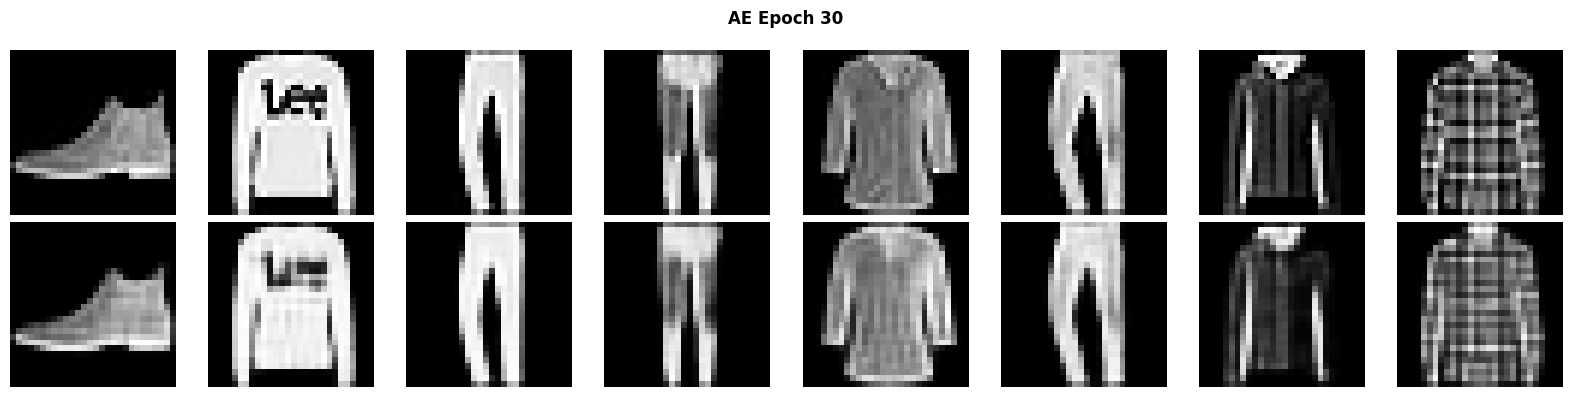


Epoch 30: val_loss improved from 0.00253 to 0.00246, saving model to best_autoencoder.keras

Epoch 30: finished saving model to best_autoencoder.keras

Epoch 31: val_loss did not improve from 0.00246

Epoch 32: val_loss did not improve from 0.00246

Epoch 33: val_loss improved from 0.00246 to 0.00236, saving model to best_autoencoder.keras

Epoch 33: finished saving model to best_autoencoder.keras

Epoch 34: val_loss improved from 0.00236 to 0.00234, saving model to best_autoencoder.keras

Epoch 34: finished saving model to best_autoencoder.keras

Epoch 35: val_loss improved from 0.00234 to 0.00231, saving model to best_autoencoder.keras

Epoch 35: finished saving model to best_autoencoder.keras

Epoch 36: val_loss did not improve from 0.00231

Epoch 37: val_loss improved from 0.00231 to 0.00231, saving model to best_autoencoder.keras

Epoch 37: finished saving model to best_autoencoder.keras

Epoch 38: val_loss improved from 0.00231 to 0.00228, saving model to best_autoencoder.keras


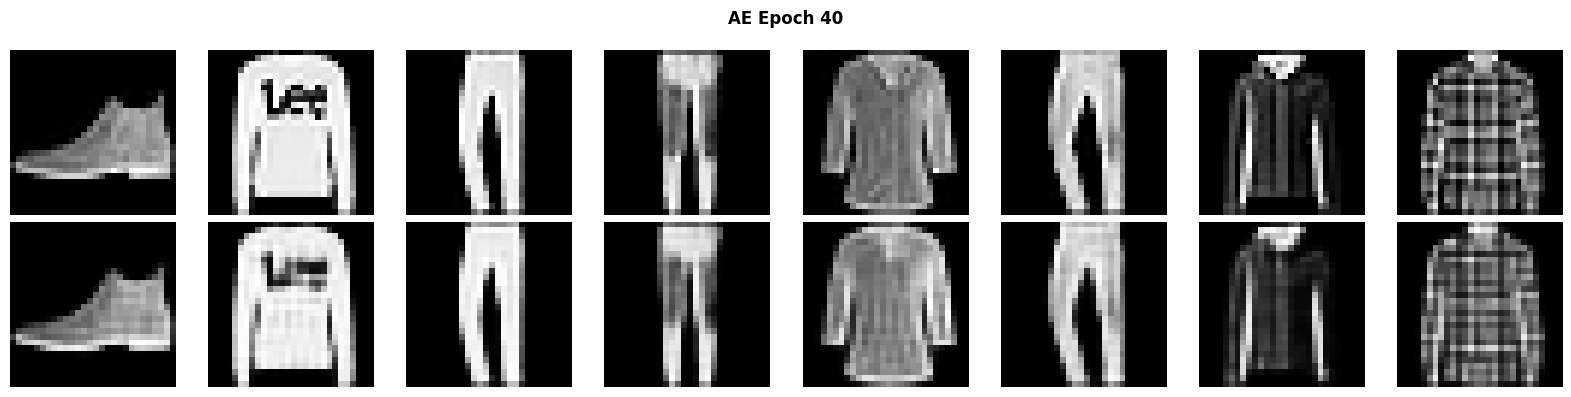


Epoch 40: val_loss did not improve from 0.00228

Epoch 41: val_loss improved from 0.00228 to 0.00219, saving model to best_autoencoder.keras

Epoch 41: finished saving model to best_autoencoder.keras

Epoch 42: val_loss did not improve from 0.00219

Epoch 43: val_loss improved from 0.00219 to 0.00218, saving model to best_autoencoder.keras

Epoch 43: finished saving model to best_autoencoder.keras

Epoch 44: val_loss did not improve from 0.00218

Epoch 45: val_loss did not improve from 0.00218

Epoch 46: val_loss improved from 0.00218 to 0.00210, saving model to best_autoencoder.keras

Epoch 46: finished saving model to best_autoencoder.keras

Epoch 47: val_loss did not improve from 0.00210

Epoch 48: val_loss improved from 0.00210 to 0.00209, saving model to best_autoencoder.keras

Epoch 48: finished saving model to best_autoencoder.keras

Epoch 49: val_loss did not improve from 0.00209


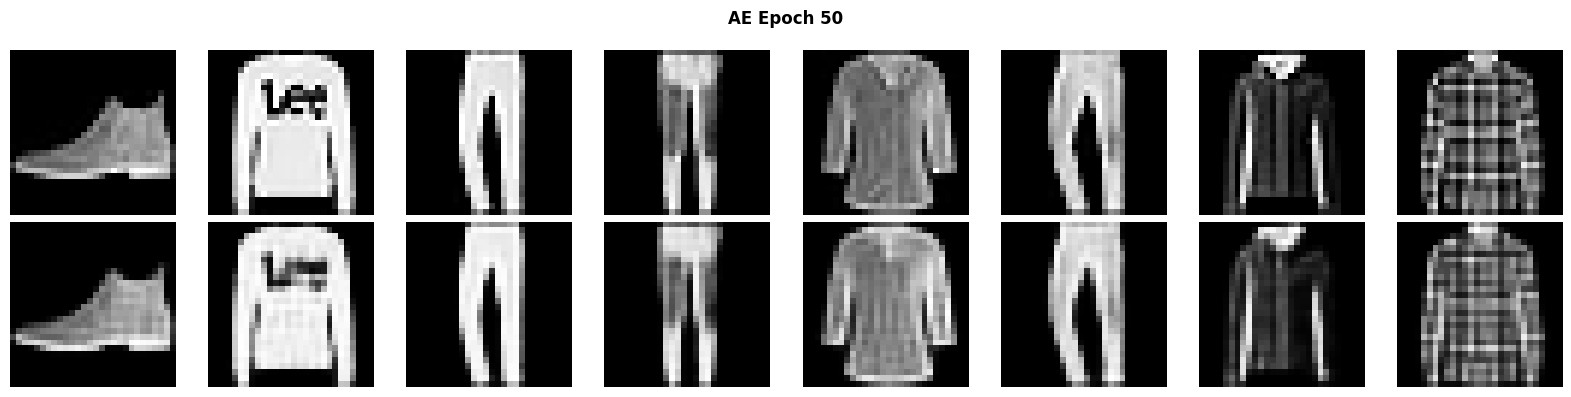


Epoch 50: val_loss improved from 0.00209 to 0.00206, saving model to best_autoencoder.keras

Epoch 50: finished saving model to best_autoencoder.keras
Restoring model weights from the end of the best epoch: 50.
✅ 최적 AE 가중치가 best_autoencoder.keras 에 저장됐습니다.


In [9]:
# ✅ 에폭별 재구성 이미지 시각화 콜백
class VisualizeCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_sample, every=10):
        self.x_sample = x_sample
        self.every = every
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every == 0:
            decoded = self.model.predict(self.x_sample, verbose=0)
            n = len(self.x_sample)
            fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
            for i in range(n):
                axes[0, i].imshow(self.x_sample[i].reshape(28, 28), cmap='gray')
                axes[0, i].axis('off')
                axes[1, i].imshow(decoded[i].reshape(28, 28), cmap='gray')
                axes[1, i].axis('off')
            axes[0, 0].set_ylabel('원본', fontsize=9)
            axes[1, 0].set_ylabel('재구성', fontsize=9)
            plt.suptitle(f'AE Epoch {epoch+1}', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

# ✅ Early Stopping: val_loss 기준, patience=5
#    restore_best_weights=True → 조기 종료 시 가장 좋았던 가중치로 자동 복원
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ✅ ModelCheckpoint: val_loss 최소일 때 자동 저장
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'best_autoencoder.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = autoencoder.fit(
    x_train, x_train,       #x_train, x_test, y_train, y_test 중 어떤것이들어갈까요?
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=0,
    callbacks=[TqdmCallback(verbose=1),
               VisualizeCallback(x_test[:8], every=10),
               early_stop,
               checkpoint_cb]
)
print('✅ 최적 AE 가중치가 best_autoencoder.keras 에 저장됐습니다.')


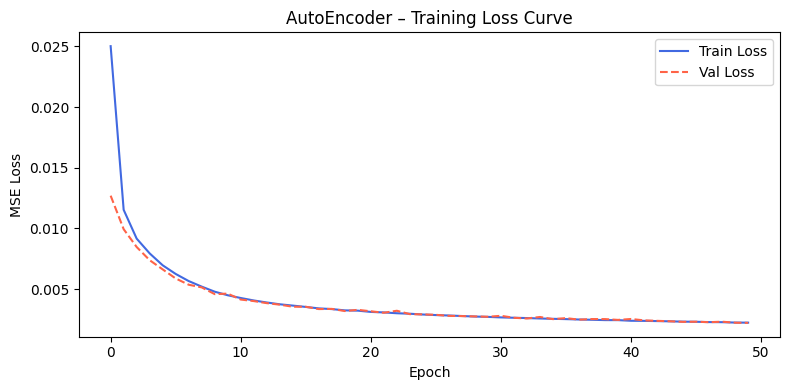

In [ ]:
# ✅ AE 학습 수렴 곡선
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('AutoEncoder – Training Loss Curve')
plt.legend(); plt.tight_layout(); plt.show()


#### **💡 Loss 곡선이 우하향할수록 모델이 잘 수렴하고 있다는 뜻입니다.**

Train/Val Loss 차이가 크면 과적합(Overfitting)을 의심해볼 수 있습니다.

### 1-4. 재복원 결과 시각화
- 이제는 맷플롯립을 이용해 x_test에 포함된 원본이미지와 재복원된 이미지를 화면에 그려봅시다.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


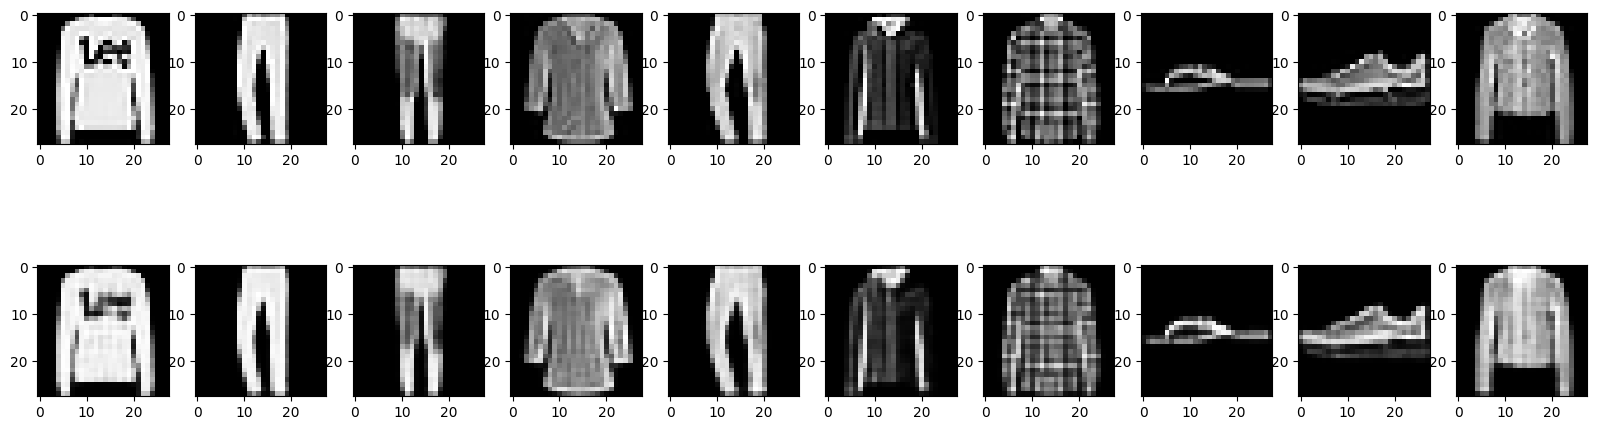

In [10]:
decoded_imgs = autoencoder.predict(x_test)  # 어떤데이터를 예측해야할까요?

n=10
plt.figure(figsize=(20, 6))
for i in range(1, n+1):
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')    #원본이미지

    ax = plt.subplot(2, n, i +n )
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')   # 재구성된 이미지
plt.show()

#### **💡 윗줄은 원래 의류 이미지고, 아랫줄은 재구성된 의류 이미지입니다!**

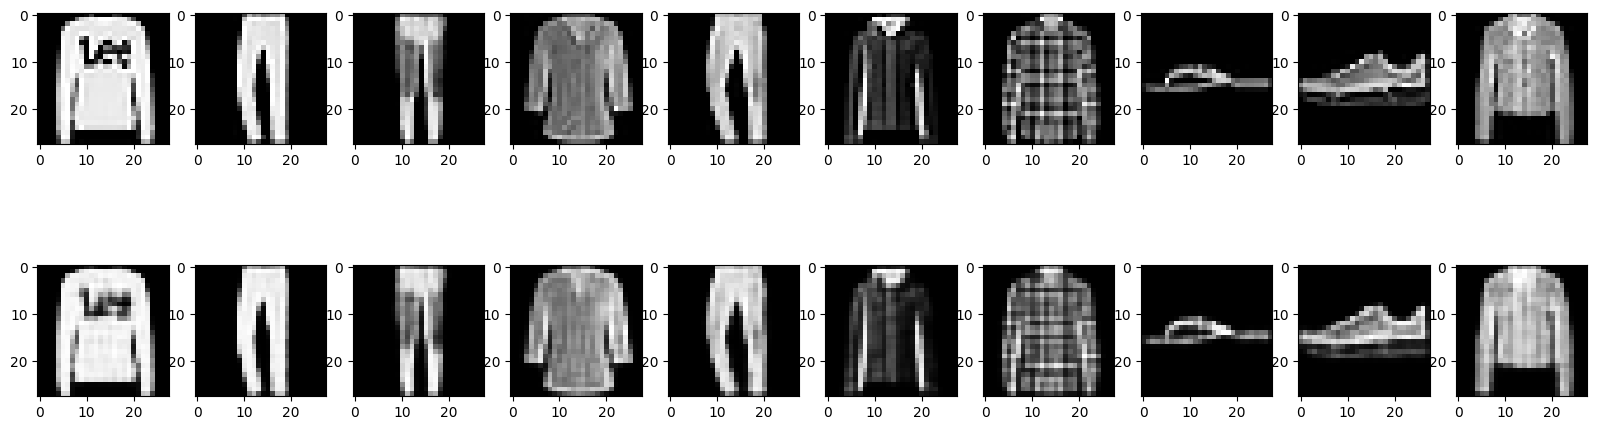

생각보다 잘됐죠? 전 잘됐는데... 안 됐으면 안타깝게 됐네요!

## 🔍 2. VAE

- VAE로도 Fashion MNIST 데이터의 이미지를 복원해볼까요?

### 2-1. 데이터 준비

In [11]:
# Fashion MNIST 데이터 로드
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# 정규화 및 reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("훈련 데이터:", x_train.shape)
print("테스트 데이터:", x_test.shape)

훈련 데이터: (60000, 28, 28, 1)
테스트 데이터: (10000, 28, 28, 1)


### 2-2. VAE 모델 정의

In [12]:
latent_dim = 32  # 잠재 공간 차원 (Fashion MNIST의 복잡도를 반영해 32로 설정)

In [13]:
# ----- 인코더 -----
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

VAE의 목적은 입력 $X$를 확률 분포 $P(z|X)$를 따르는 잠재 벡터 $z$로 인코딩하는 것입니다.

이 과정에서 $z$를 샘플링하게 되는데, 일반적인 무작위 샘플링은 역전파(Backpropagation)를 통해 모델의 가중치를 업데이트할 수 없다는 문제가 있습니다.

재매개변수화 트릭은 이 문제를 해결하여 $z$를 생성하는 과정에 '무작위성(Randomness)'을 유지하면서도 '미분 가능성(Differentiability)'을 확보합니다.

In [14]:
# 재매개변수화 트릭


def sampling(args):
    z_mean, z_log_var = args      #z의 평균과 로그분산을 샘플링합니다!
    eps = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))   # 무작위성을 줍시다! 무작위는영어로?
    return z_mean + tf.exp(0.5 * z_log_var) * eps   # return값이 잠재벡터 z의 공식이 됩니다.

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 428,608 (1.64 MB)

 Trainable params: 428,608 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ----- 디코더 -----
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
decoder = Model(latent_inputs, decoder_outputs, name="decoder")  # 디코더의 입력과 출력 변수를 넣어주세요!
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       206,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,929 (1.64 MB)

 Trainable params: 428,929 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

### 2-3. VAE 클래스 정의

In [16]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def compile(self, optimizer, **kwargs):
        super(VAE, self).compile(**kwargs)
        self.optimizer = optimizer

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # 재구성 손실 (픽셀별 MSE)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=[1,2,3])
            )
            # KL 손실
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

### 2-4. VAE 학습

In [17]:
# 모델 생성
vae = VAE(encoder, decoder)
vae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=lambda x, y: 0.0  # validation용 dummy loss
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - kl_loss: 2.4889 - loss: 92.6314 - recon_loss: 90.1425
Epoch 1: loss improved from None to 68.87714, saving model to best_vae_weights.weights.h5

Epoch 1: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - kl_loss: 4.2510 - loss: 68.8771 - recon_loss: 64.6262 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 2/30
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 7.3236 - loss: 38.8476 - recon_loss: 31.5239
Epoch 2: loss improved from 68.87714 to 36.66330, saving model to best_vae_weights.weights.h5

Epoch 2: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 7.7318 - loss: 36.6633 - recon_loss: 28.9315 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 3/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 7.8820 - loss: 33.1321 - recon_loss: 25.250

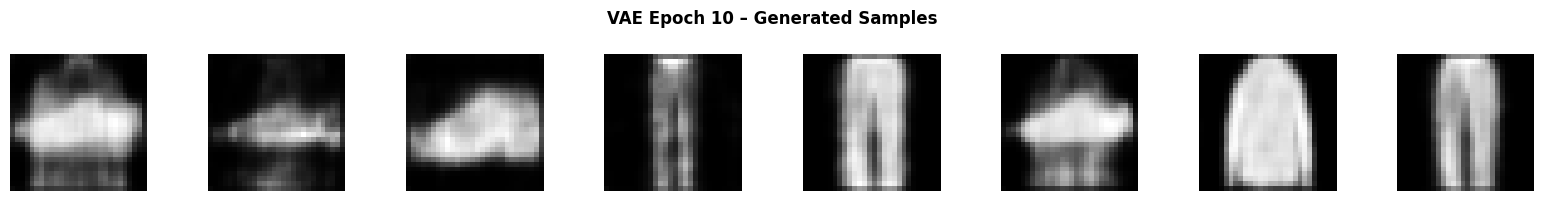


Epoch 10: loss improved from 27.43818 to 27.17290, saving model to best_vae_weights.weights.h5

Epoch 10: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 7.7073 - loss: 27.1729 - recon_loss: 19.4656 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 11/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 7.7450 - loss: 26.9784 - recon_loss: 19.2334
Epoch 11: loss improved from 27.17290 to 26.88151, saving model to best_vae_weights.weights.h5

Epoch 11: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 7.7400 - loss: 26.8815 - recon_loss: 19.1415 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 12/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 7.7706 - loss: 26.7516 - recon_loss: 18.9810
Epoch 12: loss improved from 26.88151 to 26.66981, saving model to best_vae_weights.weights.h5

E

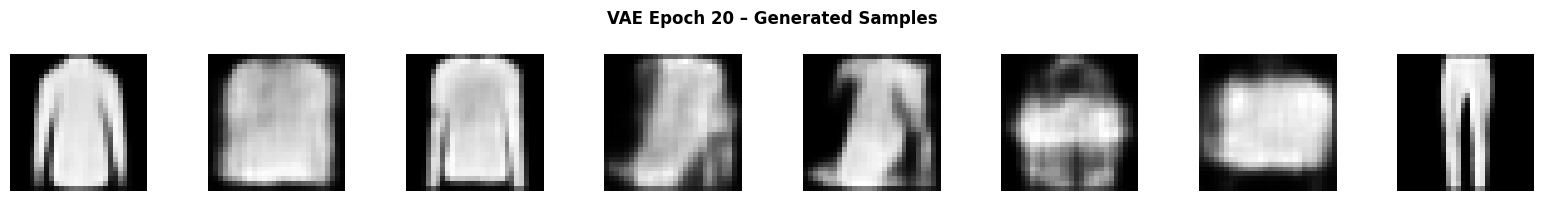


Epoch 20: loss improved from 25.59296 to 25.46754, saving model to best_vae_weights.weights.h5

Epoch 20: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 7.9557 - loss: 25.4675 - recon_loss: 17.5119 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 21/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 7.9764 - loss: 25.3871 - recon_loss: 17.4107
Epoch 21: loss improved from 25.46754 to 25.39355, saving model to best_vae_weights.weights.h5

Epoch 21: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - kl_loss: 7.9806 - loss: 25.3935 - recon_loss: 17.4129 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 22/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 7.9934 - loss: 25.3116 - recon_loss: 17.3182
Epoch 22: loss improved from 25.39355 to 25.30156, saving model to best_vae_weights.weights.h5



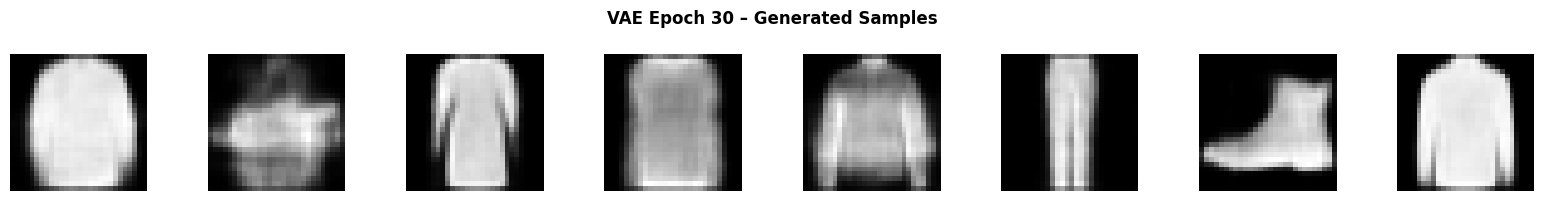


Epoch 30: loss improved from 24.80860 to 24.77296, saving model to best_vae_weights.weights.h5

Epoch 30: finished saving model to best_vae_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 8.1381 - loss: 24.7730 - recon_loss: 16.6349 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Restoring model weights from the end of the best epoch: 30.
✅ 최적 VAE 가중치가 best_vae.keras 에 저장됐습니다.


In [21]:
# ✅ 에폭별 VAE 생성 이미지 시각화 콜백
class VAEVisualCallback(tf.keras.callbacks.Callback):
    def __init__(self, decoder, every=10):
        self.decoder = decoder
        self.every = every
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every == 0:
            z_samples = tf.random.normal(shape=(8, latent_dim))
            generated  = self.decoder.predict(z_samples, verbose=0)
            fig, axes  = plt.subplots(1, 8, figsize=(16, 2))
            for i, ax in enumerate(axes):
                ax.imshow(generated[i].reshape(28, 28), cmap='gray')
                ax.axis('off')
            plt.suptitle(f'VAE Epoch {epoch+1} – Generated Samples',
                         fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

# ✅ Early Stopping
vae_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    mode='min',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# ✅ ModelCheckpoint
vae_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'best_vae_weights.weights.h5',
    monitor='loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)


# 학습
history = vae.fit(              #학습
    x_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_test, x_test), # x_train, x_test, y_train, y_test중 어떤게 들어갈까요?
    callbacks=[VAEVisualCallback(decoder, every=10),
               vae_early_stop,
               vae_checkpoint_cb]
)
print('✅ 최적 VAE 가중치가 best_vae.keras 에 저장됐습니다.')


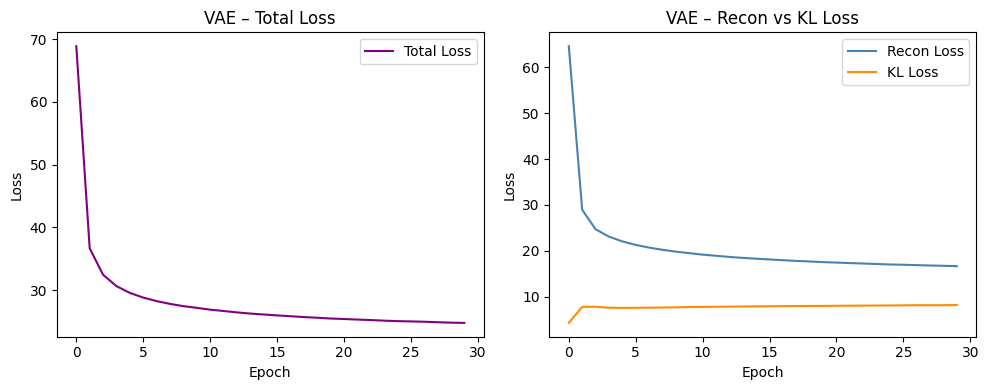

In [30]:
# ✅ VAE 학습 수렴 곡선
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Total Loss', color='purple')  # 'total_loss' → 'loss'
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('VAE – Total Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['recon_loss'], label='Recon Loss', color='steelblue')
plt.plot(history.history['kl_loss'],    label='KL Loss',    color='darkorange')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('VAE – Recon vs KL Loss'); plt.legend()

plt.tight_layout(); plt.show()

**💡 VAE 손실은 두 가지로 구성됩니다.**
- **Recon Loss**: 입력 이미지를 얼마나 정확하게 복원했는지 측정 (낮을수록 좋음)
- **KL Loss**: 잠재 공간 분포가 표준 정규분포에 얼마나 가까운지 측정 (낮을수록 좋음)

### 2-5. 재복원 결과 시각화

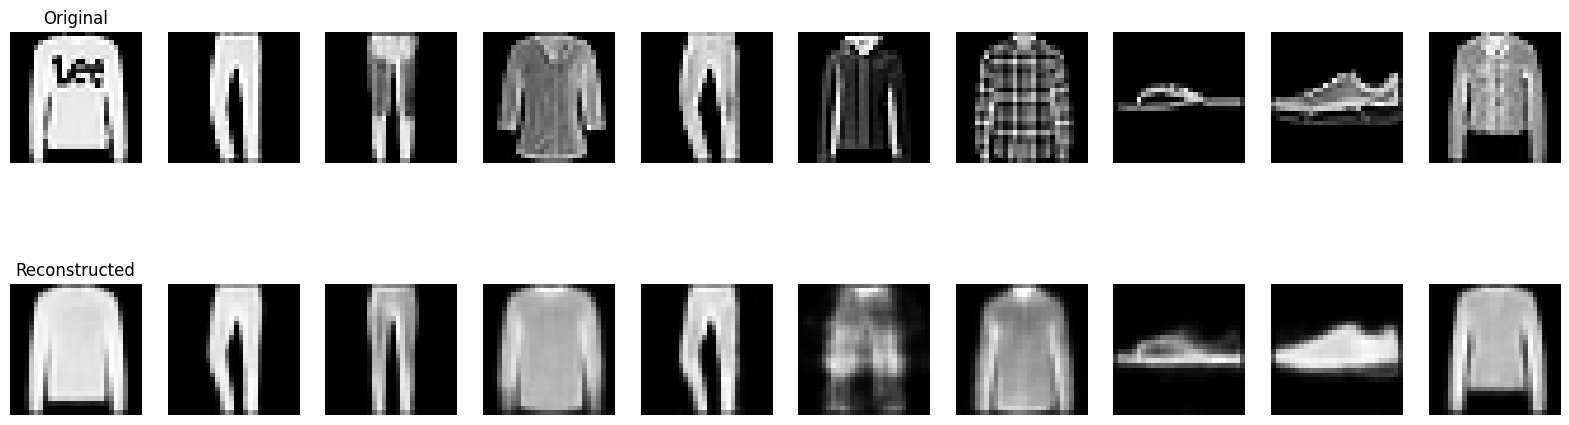

In [ ]:
# 테스트 데이터 복원
decoded_imgs = vae.decoder(vae.encoder(x_test)[2])

n = 10
plt.figure(figsize=(20, 6))
for i in range(1, n + 1):
    # 원본 이미지
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 1:
        plt.title("Original")

    # 복원 이미지
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].numpy().reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 1:
        plt.title("Reconstructed")
plt.show()


#### **💡 왜 AE보다 흐릿할까? VAE의 트레이드오프**

AE는 **재구성 손실만** 최소화하기 때문에, 잠재 공간의 특정 좌표에 각 이미지를 정확히 고정시킬 수 있습니다.  
반면 VAE는 재구성 손실에 더해 **KL 손실**로 잠재 공간을 정규분포 형태로 강제합니다.

이 과정에서 비슷한 이미지들의 잠재 벡터가 서로 겹치게 되고,  
디코더는 **여러 이미지의 평균적인 모습**을 출력하게 됩니다 → **흐릿한 재구성**

<br>


| | AE | VAE |
|--|----|----|
| 재구성 품질 | ✅ 선명 | △ 흐릿 |
| 새 이미지 생성 | ❌ 불가 | ✅ 가능 (`z ~ N(0,1)` 샘플링) |
| 잠재 공간 | 비구조적 | 정규분포 구조 |

<br>

> **VAE의 흐릿함은 버그가 아니다!**  
> "새 이미지를 생성할 수 있는 능력"을 얻기 위해 재구성 품질을 일부 포기한 것!

<br>

이 한계를 극복하기 위해 등장한 것이 **GAN**과 **Diffusion** 모델입니다.  
GAN은 판별자와의 경쟁을 통해, Diffusion은 노이즈 제거 과정을 통해 훨씬 선명한 이미지를 생성합니다.

실습해 봅시다!


## 🔍 3. GAN

이번엔 생성자(Generator)와 판별자(Discriminator)를 번갈아 학습시켜 Fashion MNIST 의류 이미지를 새로 생성해봅시다.

### 3-1. 데이터 준비

In [31]:
# Fashion MNIST 데이터 로드
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# [0, 1] → [-1, 1] 스케일링 (GAN에서는 tanh 출력 맞추기 위함)
x_train = (x_train.astype(np.float32) - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

BUFFER_SIZE = 60000
BATCH_SIZE = 256

# tf.data로 배치 구성
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


### 3-2. 생성자(Generator) 모델 정의

In [32]:
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = make_generator_model()  #위에서 정의한 생성자 함수!
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

### 3-3. 판별자(Discriminator) 모델 정의

In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                      input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

discriminator = make_generator_model()  #위에서 정의한 판별자 함수!
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

### 3-4. 손실함수 및 옵티마이저 설정

In [22]:
# ✅ 손실 함수 정의
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    # 생성자는 판별자를 '진짜'라고 속여야 하므로 레이블 = 1
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    # 판별자는 진짜=1, 가짜=0 으로 분류해야 함
    real_loss = cross_entropy(tf.ones_like(real_output),  real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss        # 총 손실은 두 손실의 합입니다!

# GAN 학습 안정화를 위해 beta_1=0.5 사용 (일반적인 GAN 권장 설정)
generator_optimizer     = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


### 3-5. 학습 루프 정의

In [23]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# 고정 시드(매번 같은 예시 생성)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch}', fontsize=14)
    plt.show()


### 3-6. GAN 학습

In [33]:
# patience를 제거하고, 최적 가중치 복원도 제거
def train_gan(dataset, epochs):
    gen_losses, disc_losses = [], []

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_losses, epoch_disc_losses = [], []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_losses.append(float(gen_loss))
            epoch_disc_losses.append(float(disc_loss))

        avg_gen  = sum(epoch_gen_losses)  / len(epoch_gen_losses)
        avg_disc = sum(epoch_disc_losses) / len(epoch_disc_losses)
        gen_losses.append(avg_gen)
        disc_losses.append(avg_disc)

        generate_and_save_images(generator, epoch + 1, seed)
        print(f'\nEpoch {epoch+1}, Gen Loss: {avg_gen:.4f}, Disc Loss: {avg_disc:.4f}')
        print(f'Time for epoch {epoch+1} is {time.time()-start:.2f} sec\n')

    return gen_losses, disc_losses

In [34]:
# 코랩 T4 기준 약 6분 정도 걸리는 코드입니다. 돌려놓고 화장실 갔다 오세요.

gen_losses, disc_losses = train_gan(train_dataset, epochs=30)


NameError: in user code:

    File "/tmp/ipykernel_1421/2079951261.py", line 15, in train_step  *
        real_output = discriminator(images, training=True)

    NameError: name 'discriminator' is not defined


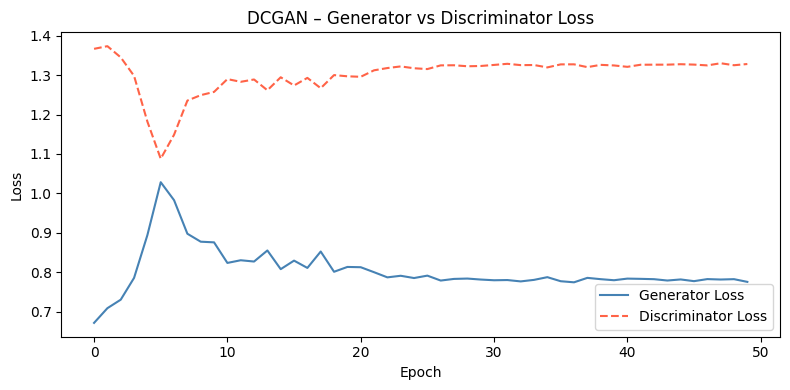

In [ ]:
# ✅ GAN 학습 수렴 곡선
plt.figure(figsize=(8, 4))
plt.plot(gen_losses,  label='Generator Loss',     color='steelblue')
plt.plot(disc_losses, label='Discriminator Loss', color='tomato', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('DCGAN – Generator vs Discriminator Loss')
plt.legend(); plt.tight_layout(); plt.show()


**💡 GAN 손실 해석 포인트**
- **이상적인 상태**: Gen Loss 와 Disc Loss 가 비슷한 수준에서 안정적으로 수렴
- **Disc Loss → 0**: 판별자가 압도적으로 강해진 상태 → 생성자가 학습하지 못함
- **Gen Loss → 0**: 생성자가 판별자를 완전히 속이는 상태 → Mode Collapse 위험

**💡 Generator Loss와 Discriminator Loss는 서로 비슷한 수준인 것이 가장 좋습니다!**

### 3-7. 최종 이미지 생성

In [26]:
# 학습이 끝난 후 새로운 이미지를 생성
noise = tf.random.normal([25, noise_dim])
generated_images = generator(noise, training=False)   #생성자!

plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(generated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
    plt.axis('off')
plt.show()

NameError: name 'generator' is not defined

**💡 첫 에포크에선 형편없는 가짜 이미지가 생성됩니다.**

**그러나 30 에포크가 지나면 이미지가 그럴 듯한 의류 이미지를 생성하는 것을 볼 수 있습니다.**

**더 많은 에포크를 지나 enerator Loss와 Discriminator Loss가 비슷하게 수렴하면 더욱 명확한 의류 이미지를 생성하겠죠?**


## 🔍 4. Diffusion Model (확산 모형)

### 4-1. 데이터 준비

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.9MB/s]


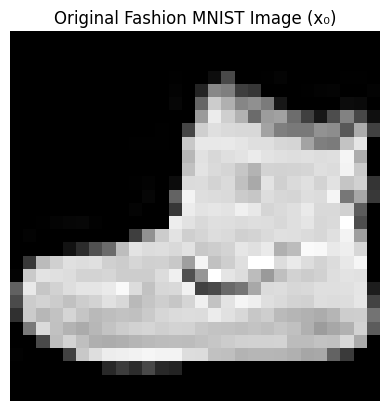

In [27]:
transform = transforms.Compose([transforms.ToTensor()])
data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(data, batch_size=64, shuffle=True)

# 샘플 하나 시각화
x0_sample = data[0][0]
plt.imshow(x0_sample.squeeze(), cmap='gray')
plt.axis('off')
plt.title("Original Fashion MNIST Image (x₀)")
plt.show()

### 4-2. 순확산 (Forward Diffusion)

In [ ]:
T = 300  # total diffusion steps
beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

In [28]:
# ✅ 배치 단위로 노이즈 추가
def add_noise(x0, t):
    noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(alpha_bar[t]).view(-1, 1, 1, 1)    # 원본데이터(x0)에 곱해지는 가중치
    sqrt_1_ab = torch.sqrt(1 - alpha_bar[t]).view(-1, 1, 1, 1)    # 노이즈(noise)에 곱해지는 가중치
    return sqrt_ab * x0 + sqrt_1_ab * noise   # 가중치에 원본데이터와 노이즈를 곱해줍시다!


In [29]:
# ✅ 순확산 시각화 (샘플 한 장)
x0 = x0_sample.unsqueeze(0).to(device)  # [1,1,28,28]
plt.figure(figsize=(12, 2))
for i, t in enumerate([0, 50, 100, 200, 299]):
    xt = add_noise(x0, torch.tensor([t], device=device))
    plt.subplot(1, 5, i + 1)
    plt.imshow(xt.squeeze().cpu(), cmap='gray')
    plt.axis('off')
    plt.title(f"t={t}")
plt.suptitle("Forward Diffusion: Adding Noise", y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


NameError: name 'alpha_bar' is not defined

<Figure size 1200x200 with 0 Axes>

**💡 노이즈가 잘 추가된 것을 확인할 수 있습니다!**

### 4-3. 역확산 (Reverse Diffusion)

In [35]:
# ✅ 타임스텝 임베딩을 사용하는 CNN 기반 denoiser
# 노이즈 제거는 타임스텝(t)에 따라 달라야 하므로 t 정보를 모델에 주입합니다.
class SimpleDenoiser(nn.Module):
    def __init__(self, T=300):
        super().__init__()
        self.T = T
        self.time_emb  = nn.Embedding(T, 64)
        self.time_proj = nn.Linear(64, 128)   # 32→64, 64→128

        self.enc1 = nn.Conv2d(1,   64,  3, padding=1)   # 32→64
        self.enc2 = nn.Conv2d(64,  128, 3, stride=2, padding=1)  # 64→128
        self.mid  = nn.Conv2d(128, 128, 3, padding=1)   # 추가: bottleneck
        self.dec1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)  # 128→64
        self.out  = nn.Conv2d(64, 1, 3, padding=1)      # 64→1

    def forward(self, x, t):
        t_emb = F.relu(self.time_proj(self.time_emb(t)))
        t_emb = t_emb.view(-1, 128, 1, 1)

        h1 = F.relu(self.enc1(x))    # [B, 64, 28, 28]
        h2 = F.relu(self.enc2(h1))   # [B, 128, 14, 14]
        h2 = h2 + t_emb             # 타임스텝 정보 주입
        h2 = F.relu(self.mid(h2))   # [B, 128, 14, 14] - bottleneck
        h3 = F.relu(self.dec1(h2))  # [B, 64, 28, 28]
        return torch.sigmoid(self.out(h3 + h1))  # skip connection

In [ ]:
model = SimpleDenoiser(T=T).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
loss_fn = nn.MSELoss()


In [ ]:
# ✅ 역확산 (점진적 노이즈 제거) - 타임스텝 t를 모델에 전달
@torch.no_grad()
def reverse_diffusion(model, steps=10):
    x = torch.randn((1, 1, 28, 28), device=device)  # 완전 노이즈에서 시작
    images = [x.cpu()]
    for i in range(steps):
        t_val = max(0, T - 1 - i * (T // steps))
        t_tensor = torch.tensor([t_val], device=device)
        denoised = model(x, t_tensor)      # ✅ t 전달
        x = x - 0.3 * (x - denoised)       # 단순 denoising step
        images.append(x.cpu())
    return images

Epoch 1, loss = 0.0539
Epoch 2, loss = 0.0423
Epoch 3, loss = 0.0400
Epoch 4, loss = 0.0391
Epoch 5, loss = 0.0384


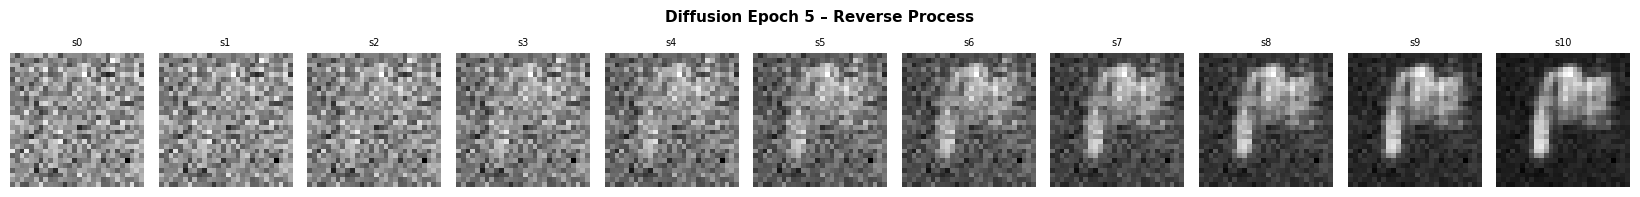

Epoch 6, loss = 0.0383
Epoch 7, loss = 0.0379
Epoch 8, loss = 0.0376
Epoch 9, loss = 0.0375
Epoch 10, loss = 0.0372


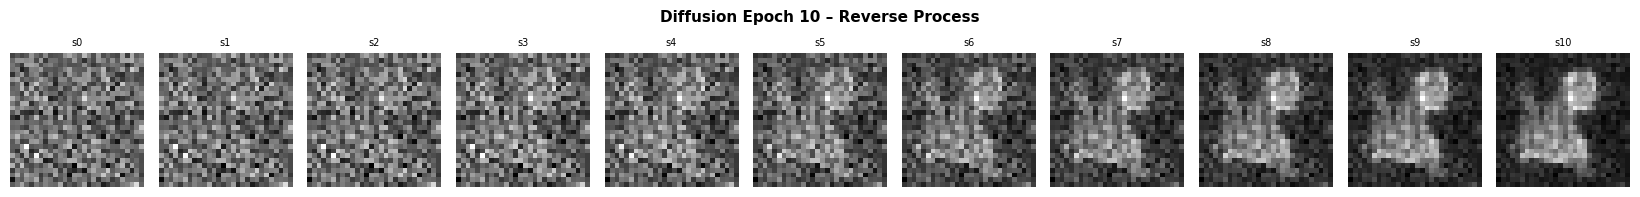

Epoch 11, loss = 0.0370
Epoch 12, loss = 0.0369
Epoch 13, loss = 0.0367
Epoch 14, loss = 0.0366
Epoch 15, loss = 0.0368


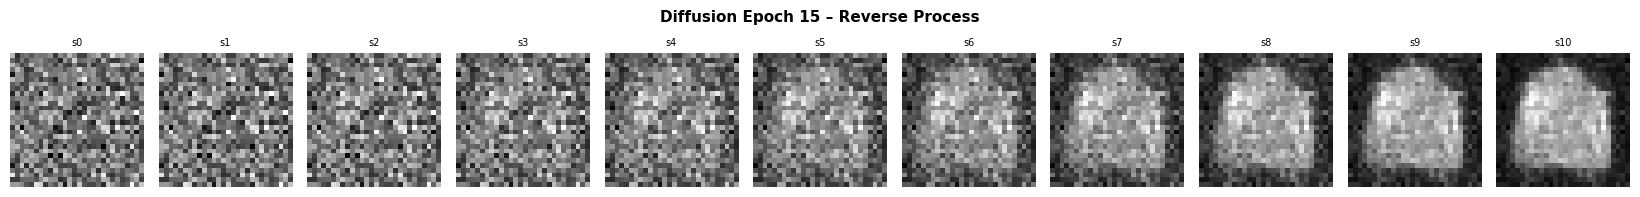

Epoch 16, loss = 0.0366
Epoch 17, loss = 0.0366
Epoch 18, loss = 0.0363
Epoch 19, loss = 0.0363
Epoch 20, loss = 0.0363


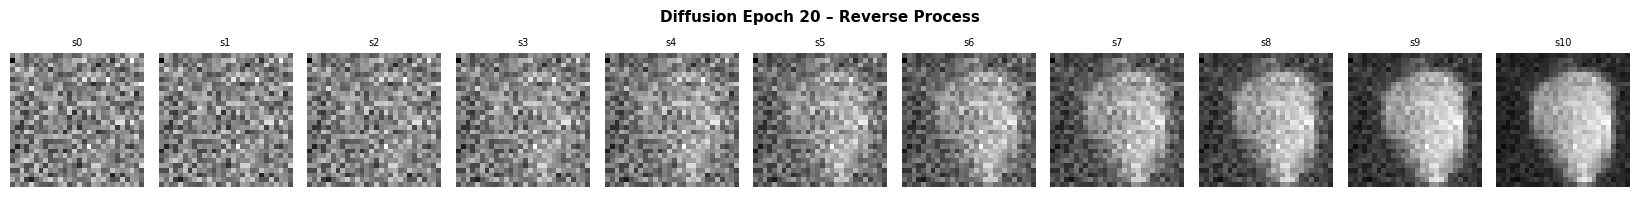

Epoch 21, loss = 0.0363
Epoch 22, loss = 0.0361
Epoch 23, loss = 0.0362
Epoch 24, loss = 0.0362
Epoch 25, loss = 0.0361


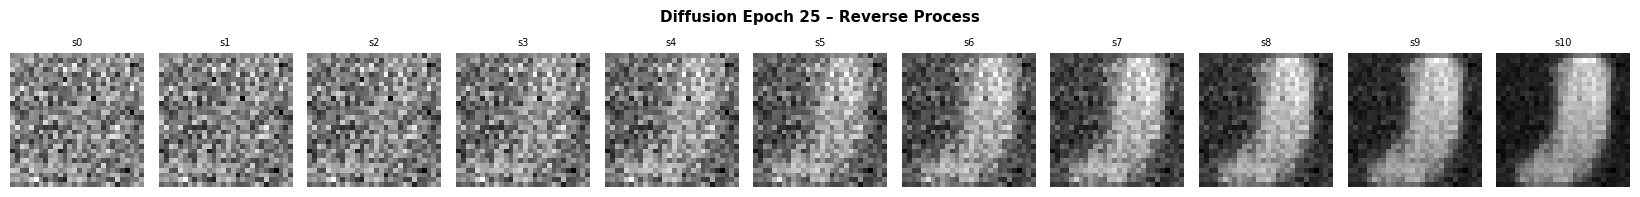

✅ 최적 Diffusion 가중치 복원 완료


In [ ]:
diff_losses    = []
best_diff_loss = float('inf')
best_diff_state = None

for epoch in range(25):
    epoch_losses = []
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        t = torch.randint(0, T, (x_batch.size(0),), device=device)
        xt = add_noise(x_batch, t)
        pred = model(xt, t)
        loss = loss_fn(pred, x_batch)

        optimizer.zero_grad()
        loss.backward()       #역전파
        optimizer.step()
        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    diff_losses.append(avg_loss)
    print(f'Epoch {epoch + 1}, loss = {avg_loss:.4f}')

    # 최적 가중치 저장
    if avg_loss < best_diff_loss:
        best_diff_loss  = avg_loss
        best_diff_state = copy.deepcopy(model.state_dict())

    # 5에폭마다 역확산 이미지 시각화
    if (epoch + 1) % 5 == 0:
        images = reverse_diffusion(model, steps=10)
        fig, axes = plt.subplots(1, len(images), figsize=(len(images) * 1.5, 2))
        for k, img in enumerate(images):
            axes[k].imshow(img.squeeze().numpy(), cmap='gray')
            axes[k].axis('off')
            axes[k].set_title(f's{k}', fontsize=7)
        plt.suptitle(f'Diffusion Epoch {epoch+1} – Reverse Process',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

# 최적 가중치 복원
if best_diff_state is not None:
    model.load_state_dict(best_diff_state)
    print('✅ 최적 Diffusion 가중치 복원 완료')


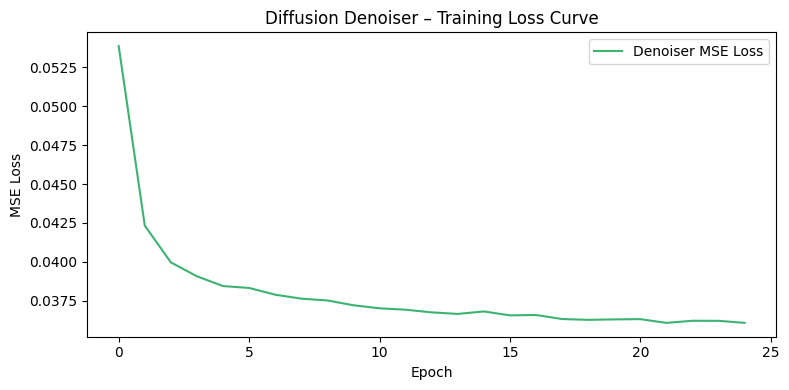

In [ ]:
# ✅ Diffusion 학습 수렴 곡선
plt.figure(figsize=(8, 4))
plt.plot(diff_losses, label='Denoiser MSE Loss', color='mediumseagreen')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Diffusion Denoiser – Training Loss Curve')
plt.legend(); plt.tight_layout(); plt.show()


**💡 Denoiser 손실이 낮을수록 노이즈 제거 성능이 향상됩니다.**
학습 과정에서 5에폭마다 역확산 이미지가 표시되어 품질 향상을 눈으로 확인할 수 있습니다.

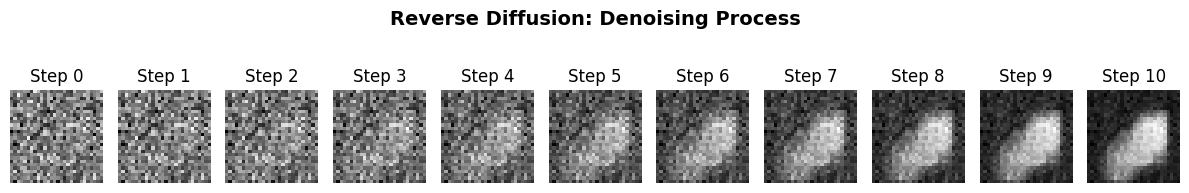

In [ ]:
# ✅ 역확산 시각화
images = reverse_diffusion(model, steps=10)     #위에서 정의한 역확산 함수!

plt.figure(figsize=(12, 2))
for i, img in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"Step {i}")
plt.suptitle("Reverse Diffusion: Denoising Process", y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

확실히 에포크를 적게 돌려서 무슨 이미지를 만들어냈는지는 모르겠지만... 노이즈에서 무언가가 만들어졌습니다!

## 수고하셨습니다~ AI 최적화로 넘어갑시다!